<a href="https://colab.research.google.com/github/Lucas66666677/xhs-jpg-models/blob/main/%E5%B0%8F%E7%B4%85%E6%9B%B8%E6%8E%92%E7%89%88%E7%A5%9E%E5%99%A8%EF%BC%8C%E6%A8%A1%E6%9D%BF1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import os
import re
import ipywidgets as widgets
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Image as IPImage

# ==========================================
# 模块一：环境与字库 (简体中文索引)
# ==========================================
FONT_PATH = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
BOLD_PATH = "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc"

def setup_environment():
    if not os.path.exists(FONT_PATH):
        print("📥 正在安装系统级中文字体包...")
        os.system("apt-get -qq update && apt-get -qq install -y fonts-noto-cjk")
    return BOLD_PATH, FONT_PATH

# ==========================================
# 模块二：像素级视觉换行
# ==========================================
def visual_wrap(text, font, max_px_width):
    lines = []
    current_line = ""
    punc_list = "。，！？）》】」』；：、"
    for char in text:
        test_line = current_line + char
        bbox = font.getbbox(test_line)
        line_w = bbox[2] - bbox[0]
        if line_w > max_px_width:
            if char in punc_list and len(current_line) > 0:
                lines.append(current_line[:-1])
                current_line = current_line[-1] + char
            else:
                lines.append(current_line)
                current_line = char
        else:
            current_line = test_line
    if current_line: lines.append(current_line)
    return lines

# ==========================================
# 模块三：核心分页算法 (原子化列点控制)
# ==========================================
def paginate_content(processed_content, fonts):
    h_limit = 1440 - 180
    pages_data = []
    current_page = []
    y = 220

    line_h_para, line_h_list = 85, 80
    paragraph_gap, inner_w = 115, 1080 - 160

    for item in processed_content:
        # 1. 预计算当前段落/列点的所有行
        if item['type'] == 'num_list':
            prefix = f"{int(item['num']):02d}."
            p_w = 110
            lines = visual_wrap(item['text'], fonts['body'], inner_w - p_w)
            line_h = line_h_list
        elif item['type'] == 'bullet_list':
            p_w = 45
            lines = visual_wrap(item['text'], fonts['body'], inner_w - p_w)
            line_h = line_h_list
        else:
            p_w = 0
            lines = visual_wrap(item['text'], fonts['body'], inner_w)
            line_h = line_h_para

        # 2. 计算这一块的总高度
        total_block_h = len(lines) * line_h

        # 3. 分页逻辑
        if item['type'] in ['num_list', 'bullet_list']:
            # 【原子控制】：如果列点在当前页放不下，且它没超过一整页的高度，就整体移到下一页
            if y + total_block_h > h_limit and total_block_h < (h_limit - 220):
                pages_data.append(current_page)
                current_page = []
                y = 220

            # 渲染列点（依然支持超长列点的物理跨页，但优先整体移动）
            for idx, line in enumerate(lines):
                if y + line_h > h_limit:
                    pages_data.append(current_page); current_page = []; y = 220
                current_page.append({
                    'type': item['type'], 'text': line, 'y': y,
                    'is_first_line': (idx == 0),
                    'prefix': prefix if (idx == 0 and item['type'] == 'num_list') else '',
                    'indent': p_w
                })
                y += line_h
        else:
            # 普通段落：允许行级拆分
            for idx, line in enumerate(lines):
                if y + line_h > h_limit:
                    pages_data.append(current_page); current_page = []; y = 220
                current_page.append({'type': 'para', 'text': line, 'y': y, 'indent': 0})
                y += line_h

        y += paragraph_gap # 段落间物理空行

    if current_page: pages_data.append(current_page)
    return pages_data

# ==========================================
# 模块四：绘图与主工厂
# ==========================================
def draw_cover(data, photo_path, fonts):
    w, h = 1080, 1440
    photo_h = 580
    canvas = Image.new('RGB', (w, h), color=(255, 255, 255))
    draw = ImageDraw.Draw(canvas)
    try:
        photo = Image.open(photo_path).convert('RGB')
        ratio = w / photo_h
        if (photo.width / photo.height) > ratio:
            pw = int(photo.height * ratio); photo = photo.crop(((photo.width - pw) // 2, 0, (photo.width + pw) // 2, photo.height))
        else:
            ph = int(photo.width / ratio); photo = photo.crop((0, (photo.height - ph) // 2, photo.width, (photo.height + ph) // 2))
        photo = photo.resize((w, photo_h), Image.Resampling.LANCZOS); canvas.paste(photo, (0, h - photo_h))
    except: pass

    margin = 80
    draw.text((margin, 60), "LUCAS 拆书实验室 | 拒绝无效内耗", font=fonts['footer'], fill=(120, 120, 120))
    draw.rectangle([margin, 130, margin + 60, 138], fill=(230, 50, 50))

    y = 200
    for line in visual_wrap(data['title'], fonts['title'], w - 160):
        bbox = draw.textbbox((0, 0), line, font=fonts['title'])
        draw.text(((w - (bbox[2] - bbox[0])) // 2, y), line, font=fonts['title'], fill=(0, 0, 0))
        y += (bbox[3] - bbox[1]) + 25

    y = max(y + 30, 450); stats = f" WORDS: {data['words']} | TIME: {data['time']} "
    s_bbox = draw.textbbox((0, 0), stats, font=fonts['stats'])
    bw, bh = s_bbox[2] - s_bbox[0] + 60, s_bbox[3] - s_bbox[1] + 30
    draw.rectangle([(w-bw)//2, y, (w+bw)//2, y + bh], outline=(180, 180, 180), width=2)
    draw.text(((w-bw)//2 + 30, y + 12), stats, font=fonts['stats'], fill=(130, 130, 130))

    y += bh + 60
    for line in visual_wrap(data['subtitle'], fonts['sub'], w - 200):
        bbox = draw.textbbox((0, 0), line, font=fonts['sub'])
        draw.text(((w - (bbox[2] - bbox[0])) // 2, y), line, font=fonts['sub'], fill=(80, 80, 80))
        y += (bbox[3] - bbox[1]) + 20
    return canvas

def create_inner_canvas(fonts, page_num, total_pages):
    w, h = 1080, 1440
    canvas = Image.new('RGB', (w, h), color=(250, 250, 250)); draw = ImageDraw.Draw(canvas); margin = 80
    draw.text((margin, 60), "LUCAS 拆书实验室 | 核心观点", font=fonts['footer'], fill=(150, 150, 150))
    draw.rectangle([margin, 130, margin + 60, 138], fill=(230, 50, 50))
    p_str = f"PAGE {page_num:02d} / {total_pages:02d}"; p_bbox = draw.textbbox((0, 0), p_str, font=fonts['footer'])
    draw.text((w - margin - (p_bbox[2]-p_bbox[0]), 60), p_str, font=fonts['footer'], fill=(180, 180, 180))
    return canvas, draw

def main_factory(article, photo_path):
    f_bold_p, f_reg_p = setup_environment()
    fonts = {
        'title': ImageFont.truetype(f_bold_p, 115, index=2), 'title_s': ImageFont.truetype(f_bold_p, 48, index=2),
        'sub': ImageFont.truetype(f_bold_p, 42, index=2), 'stats': ImageFont.truetype(f_reg_p, 40, index=2),
        'body': ImageFont.truetype(f_reg_p, 45, index=2), 'footer': ImageFont.truetype(f_reg_p, 32, index=2)
    }
    raw_paras = article['content'].replace('\r\n', '\n').strip().split('\n')
    processed = []
    for p in raw_paras:
        p = p.strip()
        if not p: continue
        m_num = re.match(r'^(\d+)\.\s+(.*)', p); m_bull = re.match(r'^[-*✦■]\s+(.*)', p)
        if m_num: processed.append({'type': 'num_list', 'num': m_num.group(1), 'text': m_num.group(2)})
        elif m_bull: processed.append({'type': 'bullet_list', 'text': m_bull.group(1)})
        else: processed.append({'type': 'para', 'text': p})

    paginated = paginate_content(processed, fonts); total_imgs = len(paginated) + 1; gen_files = []
    c_img = draw_cover(article['cover'], photo_path, fonts); c_img.save("Slide_01.jpg", quality=100); gen_files.append("Slide_01.jpg")
    for i, p_lines in enumerate(paginated):
        canvas, draw = create_inner_canvas(fonts, i + 2, total_imgs); margin = 80
        for lo in p_lines:
            if lo['type'] == 'num_list':
                if lo['is_first_line']: draw.text((margin, lo['y']), lo['prefix'], font=fonts['title_s'], fill=(230, 50, 50))
                draw.text((margin + lo['indent'], lo['y']), lo['text'], font=fonts['body'], fill=(50, 50, 50))
            elif lo['type'] == 'bullet_list':
                if lo['is_first_line']: draw.rectangle([margin, lo['y']+22, margin+14, lo['y']+36], fill=(230, 50, 50))
                draw.text((margin + lo['indent'], lo['y']), lo['text'], font=fonts['body'], fill=(50, 50, 50))
            else: draw.text((margin, lo['y']), lo['text'], font=fonts['body'], fill=(50, 50, 50))
        name = f"Slide_{i+2:02d}.jpg"; canvas.save(name, quality=100); gen_files.append(name)
    return gen_files



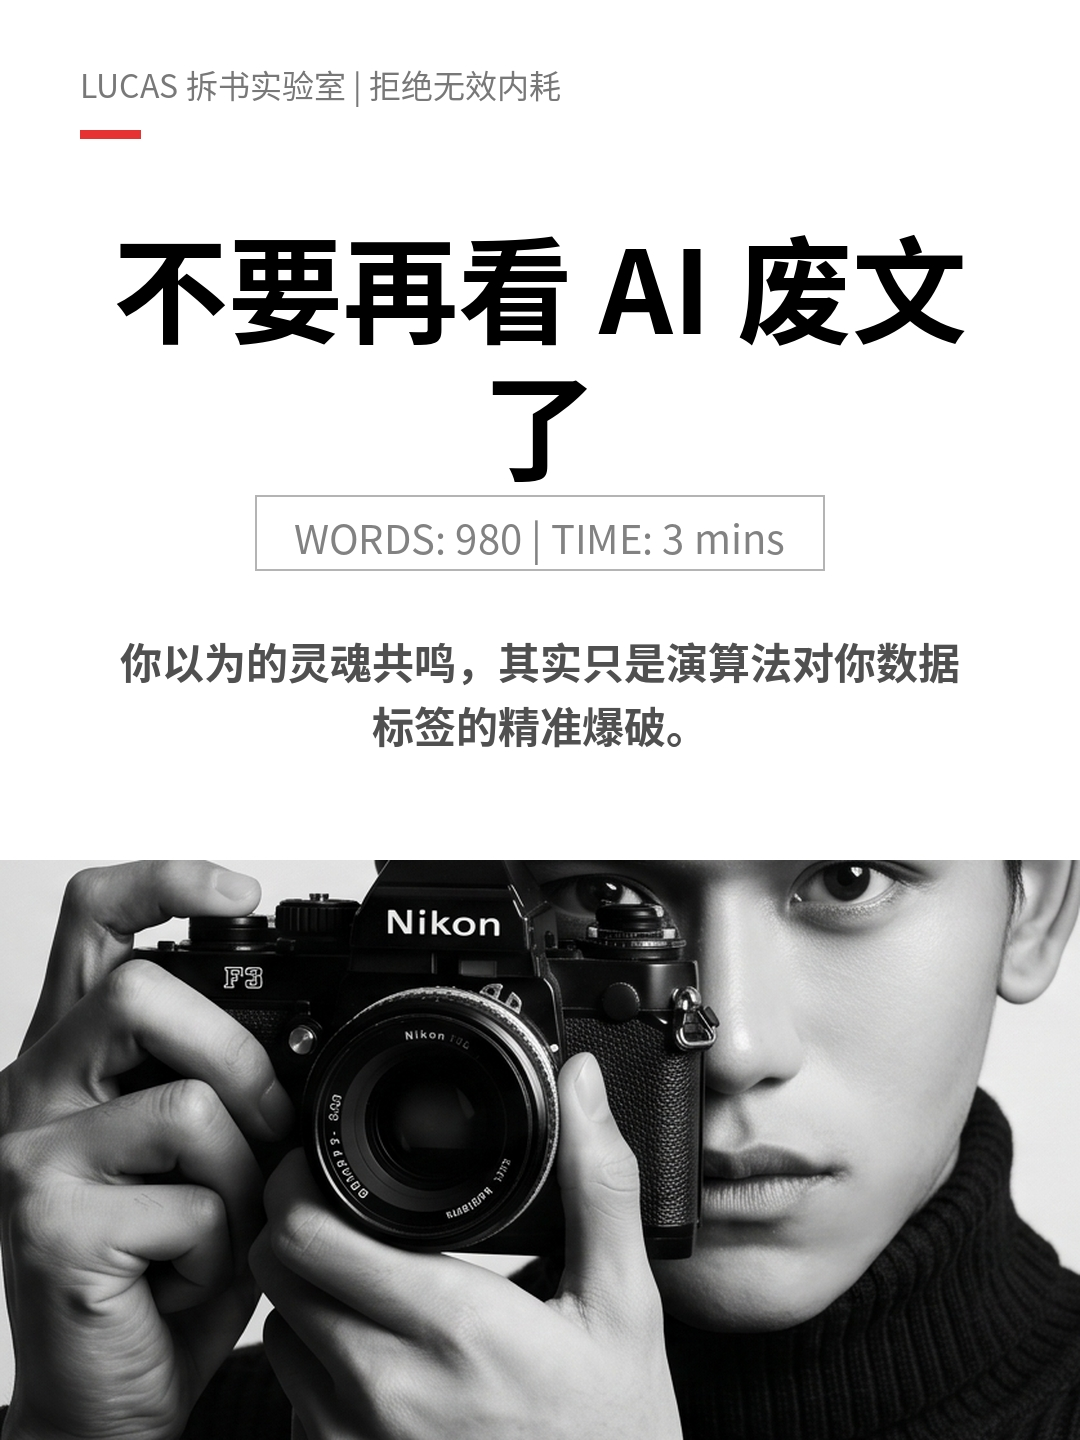

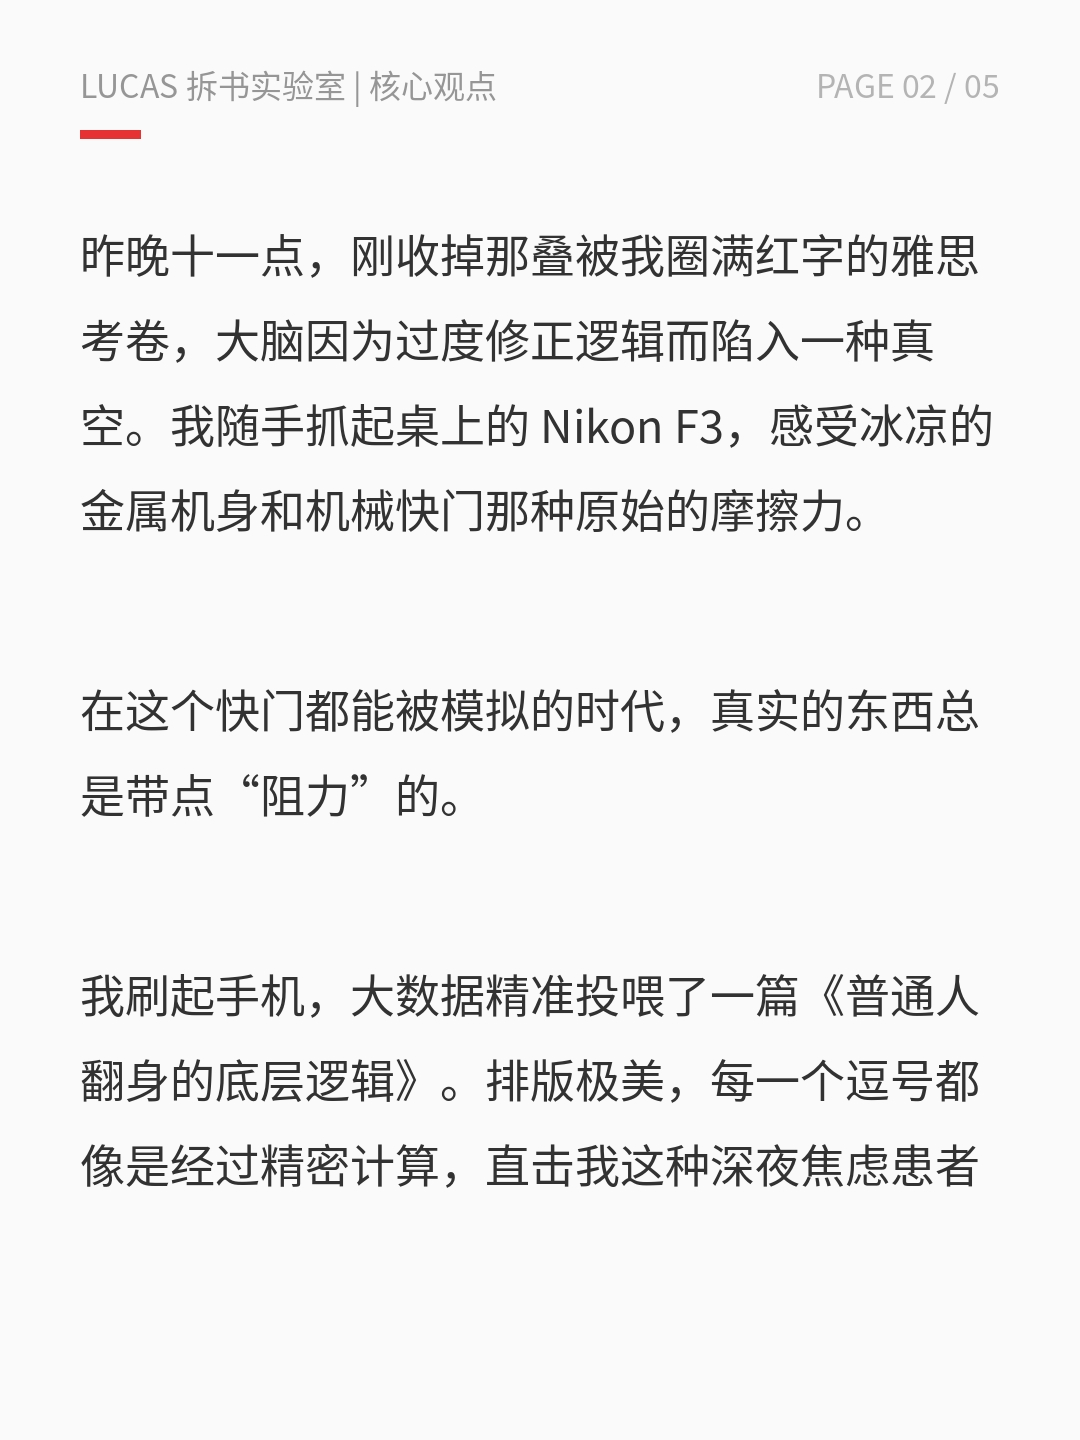

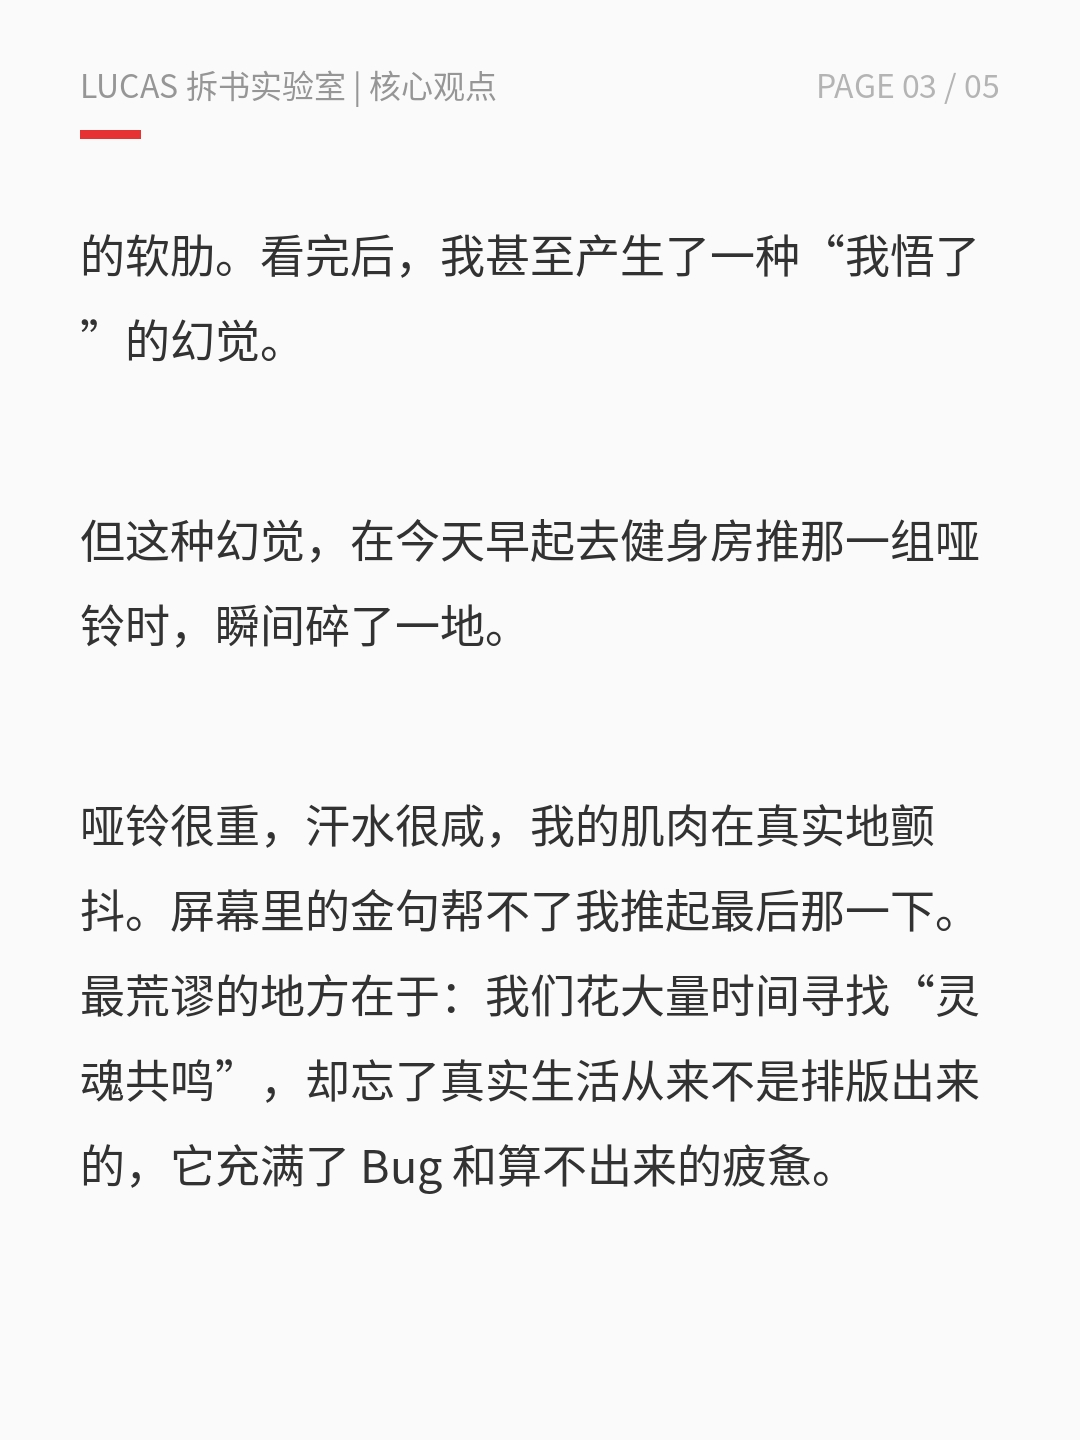

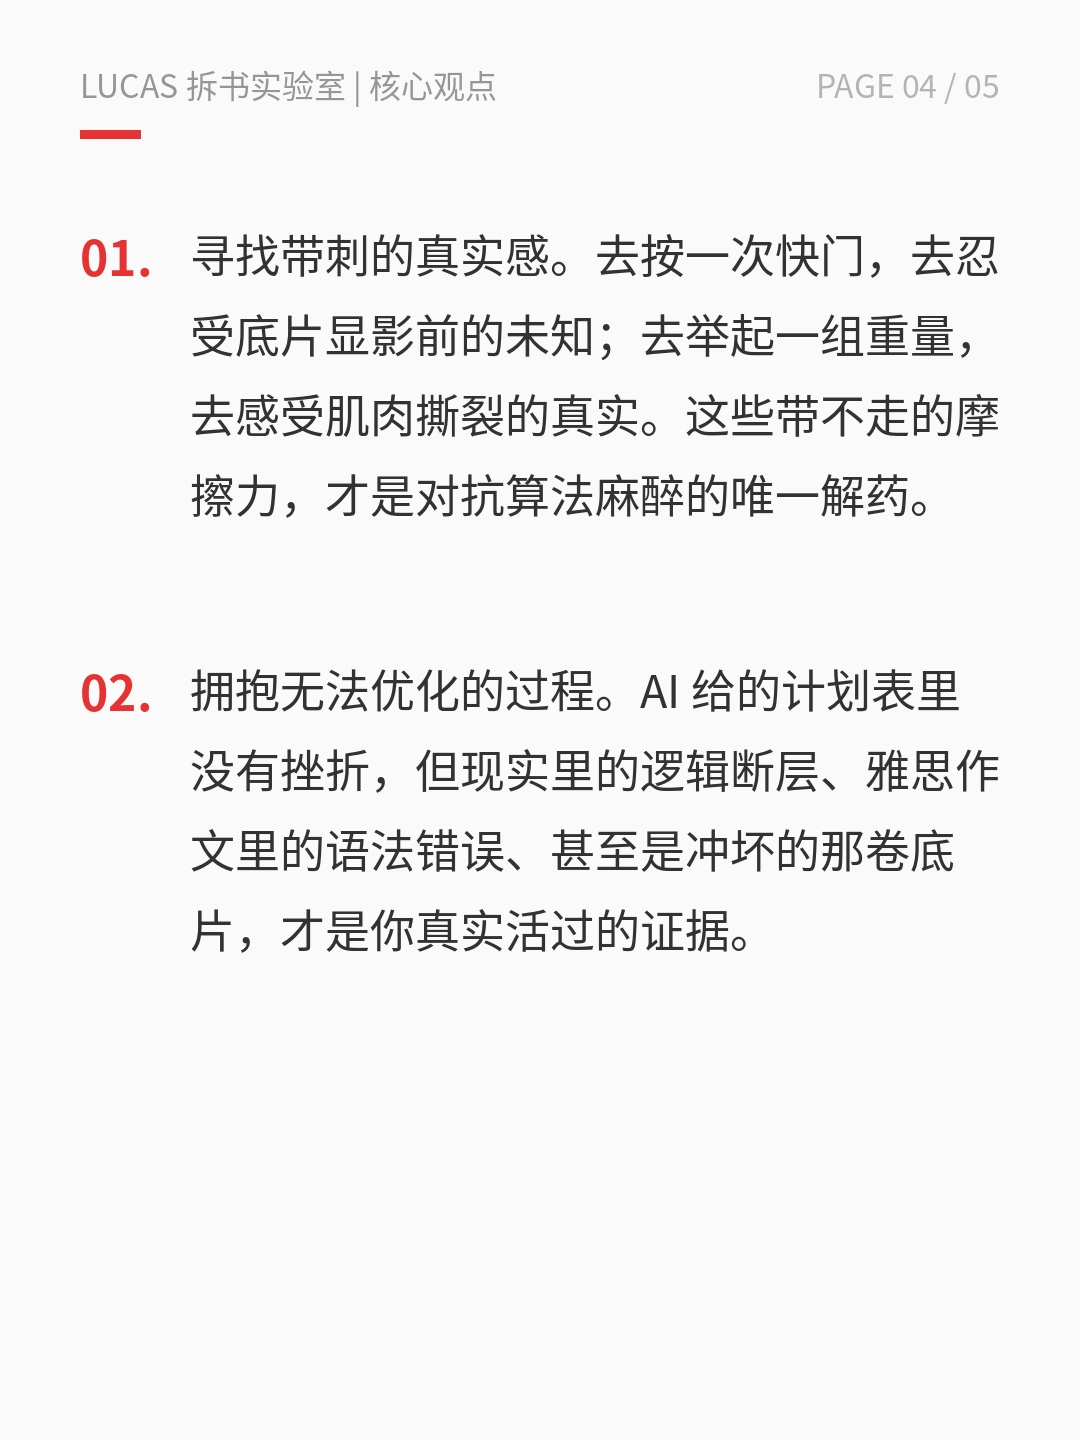

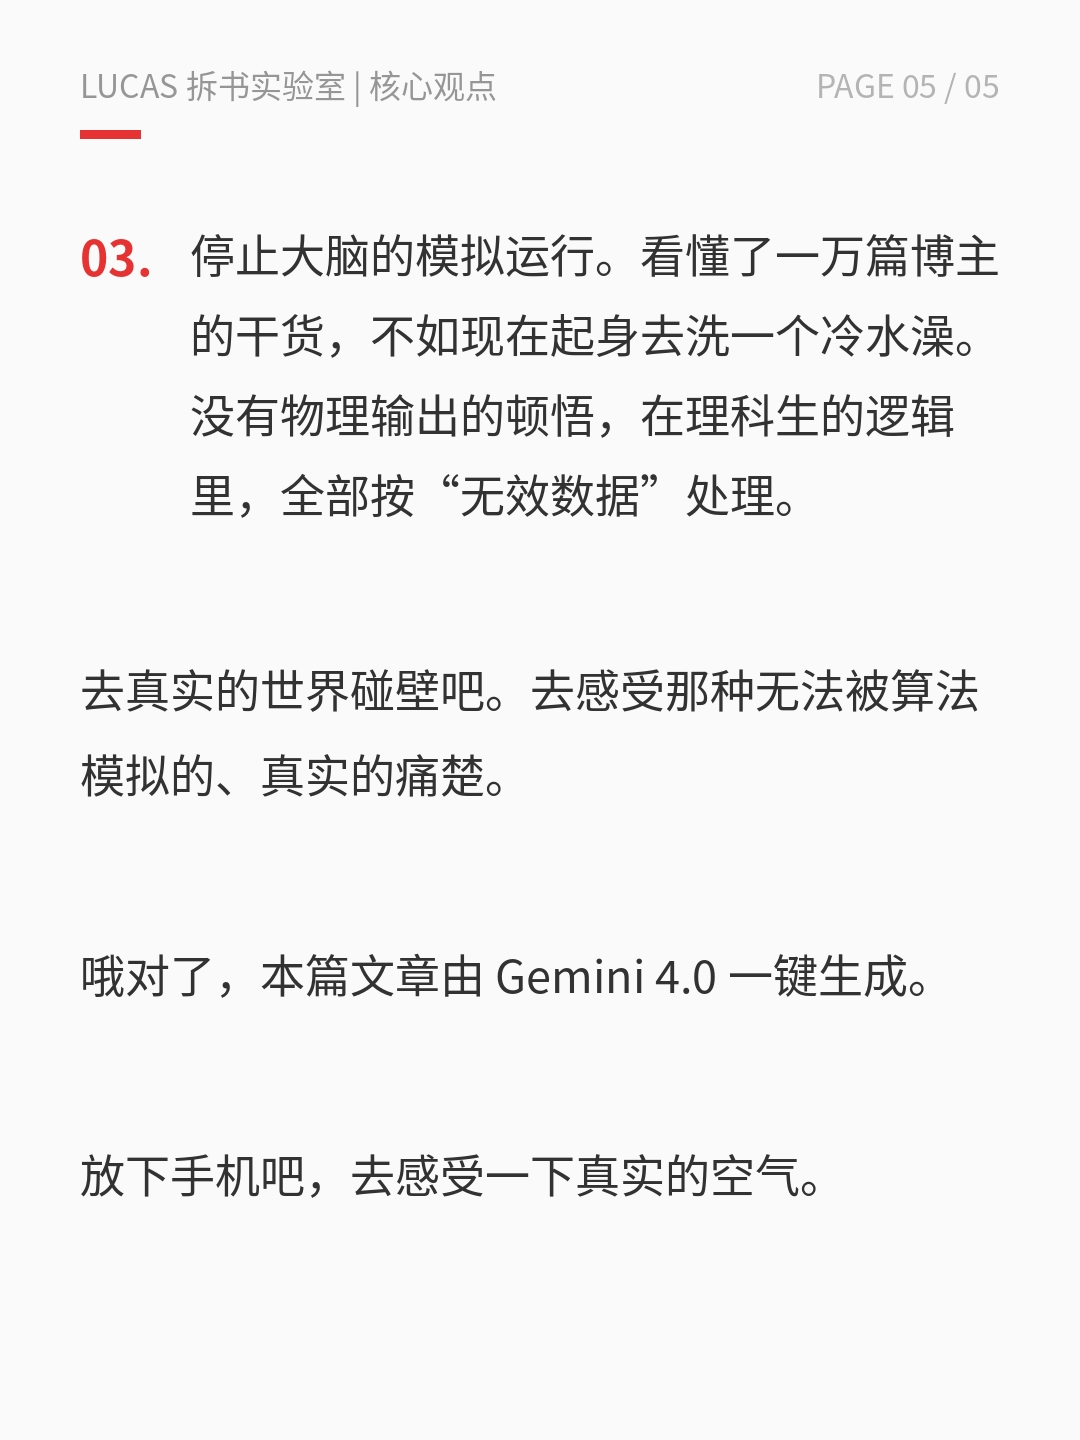

Button(button_style='success', description='一键下载 JPG 原图', icon='download', layout=Layout(height='50px', width=…

In [72]:
# ==========================================
# 🚀 资料执行区 (含一键下载)
# ==========================================
if __name__ == "__main__":
    try: from google.colab import files; IN_COLAB = True
    except: IN_COLAB = False

    my_data = {
        "cover": {
            "title": "不要再看 AI 废文了",
            "subtitle": "你以为的灵魂共鸣，其实只是演算法对你数据标签的精准爆破。",
            "words": "980", "time": "3 mins"
        },
        "content": """
昨晚十一点，刚收掉那叠被我圈满红字的雅思考卷，大脑因为过度修正逻辑而陷入一种真空。我随手抓起桌上的 Nikon F3，感受冰凉的金属机身和机械快门那种原始的摩擦力。

在这个快门都能被模拟的时代，真实的东西总是带点“阻力”的。

我刷起手机，大数据精准投喂了一篇《普通人翻身的底层逻辑》。排版极美，每一个逗号都像是经过精密计算，直击我这种深夜焦虑患者的软肋。看完后，我甚至产生了一种“我悟了”的幻觉。

但这种幻觉，在今天早起去健身房推那一组哑铃时，瞬间碎了一地。

哑铃很重，汗水很咸，我的肌肉在真实地颤抖。屏幕里的金句帮不了我推起最后那一下。最荒谬的地方在于：我们花大量时间寻找“灵魂共鸣”，却忘了真实生活从来不是排版出来的，它充满了 Bug 和算不出来的疲惫。

1. 寻找带刺的真实感。去按一次快门，去忍受底片显影前的未知；去举起一组重量，去感受肌肉撕裂的真实。这些带不走的摩擦力，才是对抗算法麻醉的唯一解药。
2. 拥抱无法优化的过程。AI 给的计划表里没有挫折，但现实里的逻辑断层、雅思作文里的语法错误、甚至是冲坏的那卷底片，才是你真实活过的证据。
3. 停止大脑的模拟运行。看懂了一万篇博主的干货，不如现在起身去洗一个冷水澡。没有物理输出的顿悟，在理科生的逻辑里，全部按“无效数据”处理。

去真实的世界碰壁吧。去感受那种无法被算法模拟的、真实的痛楚。

哦对了，本篇文章由 Gemini 4.0 一键生成。

放下手机吧，去感受一下真实的空气。
        """
    }

    all_files = main_factory(my_data, "test_photo.jpg")
    for f in all_files: display(IPImage(f, width=350))

    if IN_COLAB:
        def on_dl(b):
            for f in all_files: files.download(f)
        btn = widgets.Button(description="一键下载 JPG 原图", button_style='success', icon='download', layout=widgets.Layout(width='300px', height='50px'))
        btn.on_click(on_dl); display(btn)